#Questão de negócio:
- Verificar se os dados tem alguma correlação com as notas finais dos alunos e se é possível prever as notas dos aluno

In [2]:
import pandas as pd
#gráfico
import seaborn as sns
#estatística
import statsmodels.api as sm

In [3]:
df = pd.read_csv('../data-scripts/7/Base_Notas_v3.csv', index_col='id')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   horas_estudo        30 non-null     float64
 1   aulas_participadas  30 non-null     int64  
 2   sono_medio          30 non-null     float64
 3   nota_exame          30 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 1.1 KB


In [4]:
df.describe().round(2)

,horas_estudo,aulas_participadas,sono_medio,nota_exame
count,30.00,30.00,30.00,30.00
mean,4.62,9.80,7.06,71.81
std,1.80,2.87,0.97,8.88
min,1.17,5.00,4.38,54.48
25%,3.82,8.00,6.54,66.41
50%,4.53,10.00,7.21,71.40
75%,5.72,12.00,7.82,78.10
max,8.16,14.00,8.56,89.47


In [5]:
display(df.round(2))

,horas_estudo,aulas_participadas,sono_medio,nota_exame
id,,,,
0,5.99,8,7.34,76.12
1,4.72,11,5.24,60.93
2,6.30,12,7.32,81.73
3,8.05,7,6.61,82.70
4,4.53,5,6.32,70.66
5,4.53,8,7.61,67.76
6,8.16,6,8.03,78.65
7,6.53,12,7.93,82.49
8,4.06,8,6.16,70.14


<Axes: xlabel='horas_estudo', ylabel='nota_exame'>

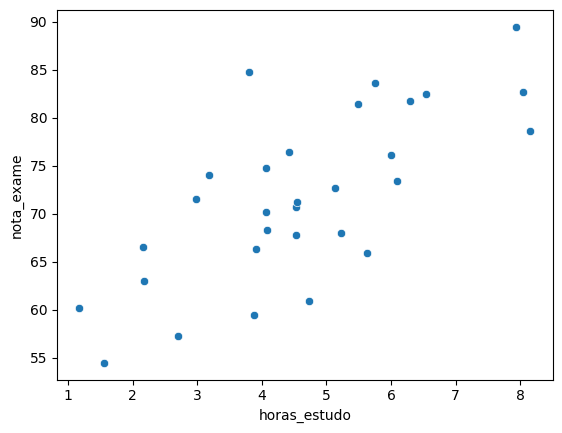

In [6]:
#eixo explicativo = x
#eixo alvo = y
sns.scatterplot(df, x='horas_estudo', y='nota_exame')

<Axes: xlabel='aulas_participadas', ylabel='nota_exame'>

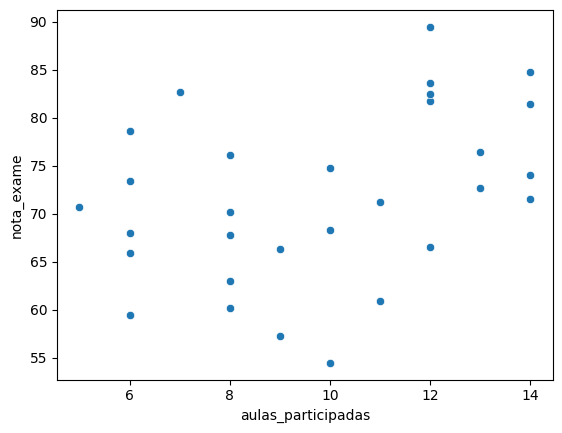

In [7]:
sns.scatterplot(df, x='aulas_participadas', y='nota_exame')

<Axes: xlabel='sono_medio', ylabel='nota_exame'>

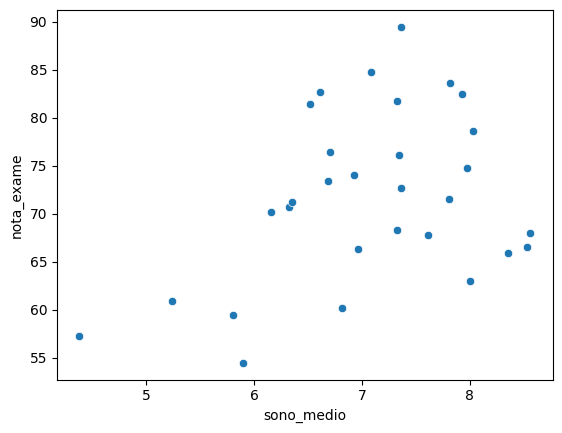

In [8]:
sns.scatterplot(df, x='sono_medio', y='nota_exame')

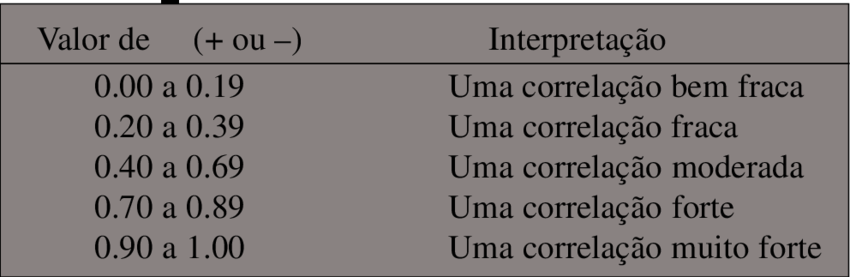

In [9]:
# Correlação de Pearson
df.corr()

,horas_estudo,aulas_participadas,sono_medio,nota_exame
horas_estudo,1.000000,-0.136144,0.215949,0.721178
aulas_participadas,-0.136144,1.000000,0.037439,0.385559
sono_medio,0.215949,0.037439,1.000000,0.370024
nota_exame,0.721178,0.385559,0.370024,1.000000


<Axes: >

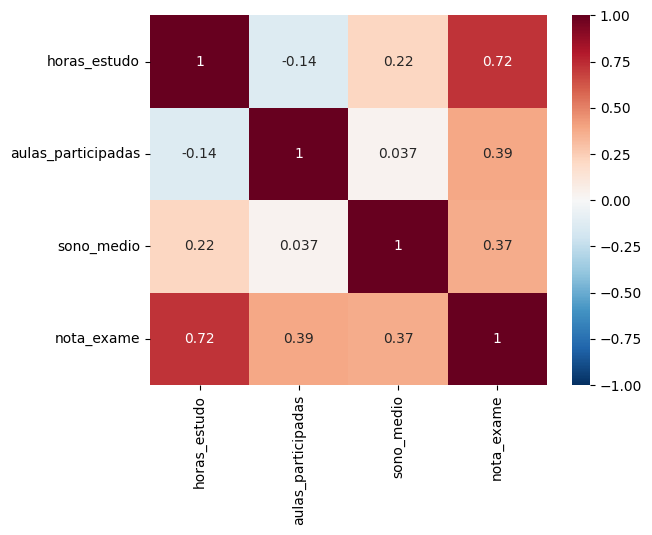

In [10]:
sns.heatmap(df.corr(),
    vmax=1,
    vmin=-1,
    cmap='RdBu_r',
    annot=True
)

In [11]:
#variável alvo
y = df['nota_exame']

#variável explicativa
df['intercepto'] = 1
x = df[['intercepto','horas_estudo', 'aulas_participadas', 'sono_medio']]

In [12]:
#ajuste do modelo
modelo = sm.OLS(y,x)

#treinamento do modelo
resultado = modelo.fit()

In [13]:
print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:             nota_exame   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     33.24
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           4.76e-09
Time:                        00:12:25   Log-Likelihood:                -83.926
No. Observations:                  30   AIC:                             175.9
Df Residuals:                      26   BIC:                             181.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
intercepto            27.9742      6

In [14]:
df['nota_exame_prevista'] = df['intercepto'] * 27.9742 + df['horas_estudo'] * 3.6754 + df['aulas_participadas'] * 1.4845 + df['sono_medio'] * 1.7408

In [15]:
df.head(10).round(2)

,horas_estudo,aulas_participadas,sono_medio,nota_exame,intercepto,nota_exame_prevista
id,,,,,,
0,5.99,8,7.34,76.12,1,74.66
1,4.72,11,5.24,60.93,1,70.78
2,6.30,12,7.32,81.73,1,81.68
3,8.05,7,6.61,82.70,1,79.45
4,4.53,5,6.32,70.66,1,63.06
5,4.53,8,7.61,67.76,1,69.76
6,8.16,6,8.03,78.65,1,80.85
7,6.53,12,7.93,82.49,1,83.61
8,4.06,8,6.16,70.14,1,65.50


<Axes: xlabel='aulas_participadas', ylabel='nota_exame'>

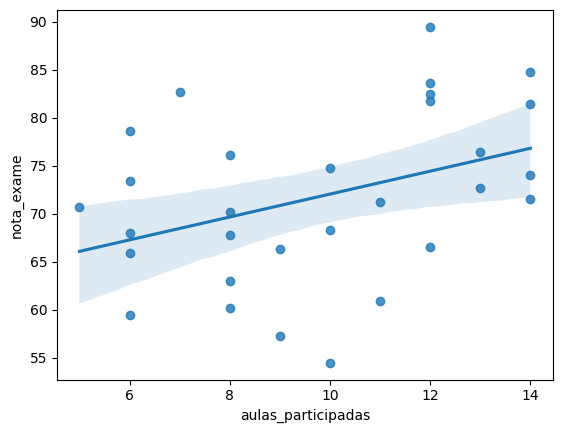

In [16]:
sns.regplot(df, x='aulas_participadas', y='nota_exame')

<Axes: xlabel='horas_estudo', ylabel='nota_exame'>

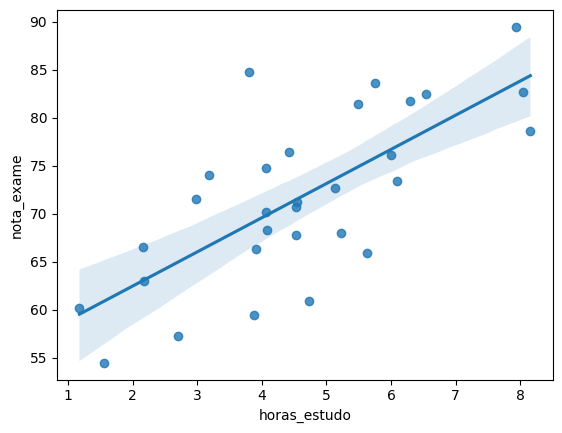

In [17]:
sns.regplot(df, x='horas_estudo', y='nota_exame')

<Axes: xlabel='sono_medio', ylabel='nota_exame'>

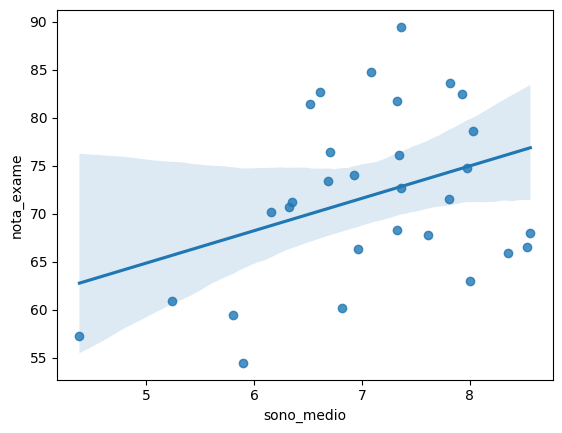

In [18]:
sns.regplot(df, x='sono_medio', y='nota_exame')

#Relatório:
- As horas de estudo têm uma correlação forte com a nota do exame, cerca de 72%, quanto mais horas de estudo, há uma forte tendência que o aluno tire mais nota. Porém, as aulas participadas e o sono médio têm pouca correlação com a nota do exame (38% e 37% respectivamente), influencia no resultado, mas pouco.
- É possível prever as notas do exame com base nas horas de estudo e nas aulas participadas, podendo explicar 79% das notas baseando-se nos dados informados, com uma aleatoriedade aceitável.